# mlops
## the questions that are needed to ask for the deployment
* what is my most ideal ml model deployment scenarion(works everytime with speed of light)
* where is my model goint to go?(on device and cloud)
* how is my model going to fuction?(online real time and offline batch)

In [2]:
# the dataset we are gonna use for the forr vision mini model is pizza steak shushi 20%
import torch
import torchvision
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
from pathlib import Path
data_20_percent_path=Path("data/pizza_steak_sushi_20_percent")
data_20_percent_path

WindowsPath('data/pizza_steak_sushi_20_percent')

In [4]:
#setup training and test paths
train_dir=data_20_percent_path/"train"
test_dir=data_20_percent_path/"test"
train_dir,test_dir

(WindowsPath('data/pizza_steak_sushi_20_percent/train'),
 WindowsPath('data/pizza_steak_sushi_20_percent/test'))

we are going to train two model effecientnetb2 and vit feature extractor and compare their accuracy and latency before deployment

In [5]:
#creating effnetb2 feature extractor
import torchvision
#pretrained weight(transfer the learnings)
effnetb2_weights=torchvision.models.EfficientNet_B2_Weights.DEFAULT

#get effnetb2 transofrmer
effnetb2_transforms=effnetb2_weights.transforms()

#setup pretrained model instance
effnetb2=torchvision.models.efficientnet_b2(weights=effnetb2_weights)

#freeze the base layer in the model(this wil stop all layers from training)
for param in effnetb2.parameters():
    param.requires_grad=False

In [6]:
from torchinfo import summary
summary(model=effnetb2,
        input_size=(1,3,224,224),
        col_names=["input_size","output_size","num_params","trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 1000]            --                   False
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 16,

In [7]:
effnetb2.classifier

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1408, out_features=1000, bias=True)
)

In [8]:
#set
from helper_functions import set_seeds
from torch import nn
set_seeds()
effnetb2.classifier=nn.Sequential(
    nn.Dropout(p=0.3,inplace=True),
    nn.Linear(in_features=1408,out_features=3,bias=True)
)

In [9]:
from torchinfo import summary
summary(model=effnetb2,
        input_size=(1,3,224,224),
        col_names=["input_size","output_size","num_params","trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 3]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

In [10]:
#creating the fuction for making the effnetb2 feature extractor
import torchvision
import torch
from torch import nn
def create_effnetb2_model(num_classes:int=3,
                          seed:int=42):
   
    #pretrained weight(transfer the learnings)
    weights=torchvision.models.EfficientNet_B2_Weights.DEFAULT

    #get effnetb2 transofrmer
    transforms=weights.transforms()

    #setup pretrained model instance
    model=torchvision.models.efficientnet_b2(weights=weights)

    #freeze the base layer in the model(this wil stop all layers from training)
    for param in model.parameters():
        param.requires_grad=False

    #change classifier head with random seed for reproducibility
    torch.manual_seed(seed)
    model.classifier=nn.Sequential(
        nn.Dropout(p=0.3,inplace=True),
        nn.Linear(in_features=1408,out_features=num_classes)
    )
    return model,transforms

In [11]:
effnetb2,effnetb2_transforms=create_effnetb2_model(num_classes=3,seed=42)

In [12]:
effnetb2_transforms

ImageClassification(
    crop_size=[288]
    resize_size=[288]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [13]:
from torchinfo import summary
summary(model=effnetb2,
        input_size=(1,3,224,224),
        col_names=["input_size","output_size","num_params","trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 3]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

In [14]:
#creating dataloaders for effnetb2
from going_modular import data_setup
train_dataloader_effnetb2,test_dataloader_effnetb2,class_names=data_setup.create_dataloaders(train_dir=train_dir,
                                                                                             test_dir=test_dir,
                                                                                             transform=effnetb2_transforms,
                                                                                             batch_size=32)

In [15]:
len(train_dataloader_effnetb2),len(test_dataloader_effnetb2),class_names

(15, 5, ['pizza', 'steak', 'sushi'])

In [16]:
#training the effnetb2 feature extractor
from going_modular import engine
#loss fun
loss_fn=torch.nn.CrossEntropyLoss()

#optimizer
optimizer=torch.optim.Adam(params=effnetb2.parameters(),
                           lr=1e-3)

#training function 
set_seeds()
effnetb2_results=engine.train(model=effnetb2,
                              train_dataloader=train_dataloader_effnetb2,
                              test_dataloader=test_dataloader_effnetb2,
                              epochs=10,#no of epochs taken from the 8_experiment_tracking
                              optimizer=optimizer,
                              loss_fn=loss_fn,
                              device=device)


 10%|█         | 1/10 [00:06<00:56,  6.28s/it]

Epoch: 1 | train_loss: 0.9832 | train_acc: 0.5750 | test_loss: 0.7411 | test_acc: 0.9409


 20%|██        | 2/10 [00:12<00:47,  5.97s/it]

Epoch: 2 | train_loss: 0.7182 | train_acc: 0.8479 | test_loss: 0.5867 | test_acc: 0.9347


 30%|███       | 3/10 [00:17<00:40,  5.78s/it]

...

Epoch: 8 | train_loss: 0.3817 | train_acc: 0.9042 | test_loss: 0.3440 | test_acc: 0.9352


 90%|█████████ | 9/10 [00:50<00:05,  5.49s/it]

Epoch: 9 | train_loss: 0.3740 | train_acc: 0.8833 | test_loss: 0.3111 | test_acc: 0.9256


100%|██████████| 10/10 [00:55<00:00,  5.60s/it]

Epoch: 10 | train_loss: 0.3710 | train_acc: 0.8625 | test_loss: 0.2805 | test_acc: 0.9625


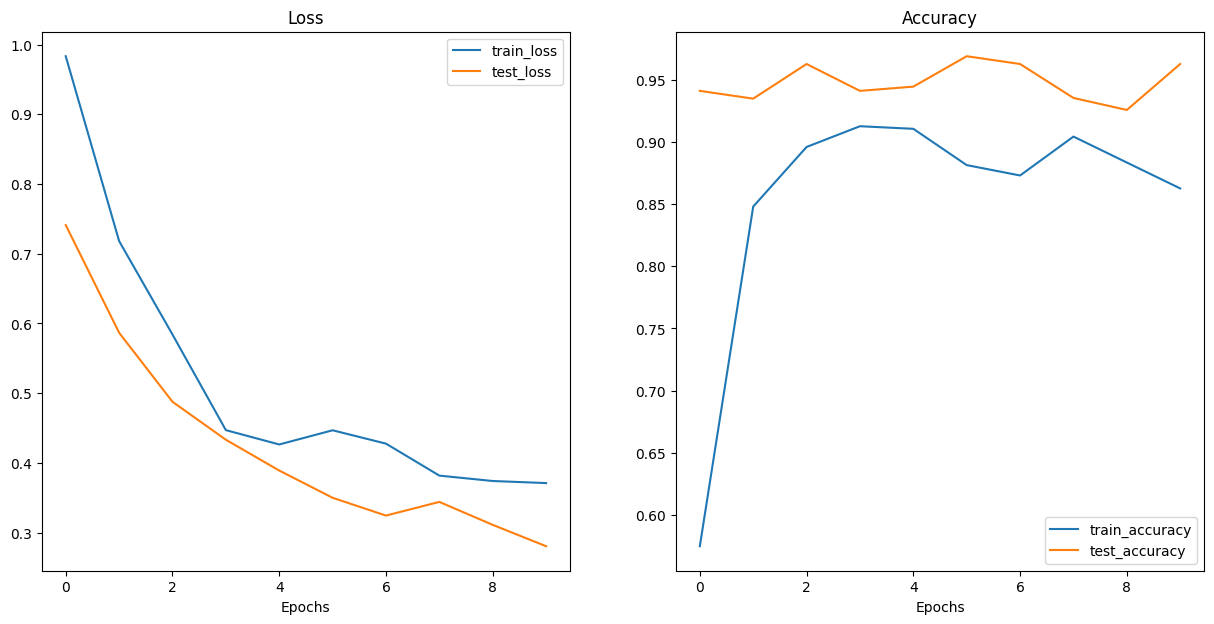

In [17]:
#visulainzing the loss curve
from going_modular.helper_functions import plot_loss_curves
plot_loss_curves(effnetb2_results)

In [18]:
# saving effnetb2 feature extractor
from going_modular import utils

utils.save_model(model=effnetb2,
                 target_dir="models",
                 model_name="10_pretrained_effnetb2_feature_extractor_pizza_stea_sushi_20_percent.pth")


[INFO] Saving model to: models\10_pretrained_effnetb2_feature_extractor_pizza_stea_sushi_20_percent.pth


In [19]:
#size of the model
from pathlib import Path

pretrained_effnetb2_model_size=Path("models/10_pretrained_effnetb2_feature_extractor_pizza_stea_sushi_20_percent.pth").stat().st_size/(1024*1024)
print(f"The size of the pretrained effnet model is :{round(pretrained_effnetb2_model_size,2)} MB")

The size of the pretrained effnet model is :29.86 MB


In [20]:
#count number of parameters in effnetb2
effnetb2_total_params=sum(torch.numel(param) for param in effnetb2.parameters())

effnetb2_total_params

7705221

In [21]:
#creating a dictionary with effnetb2 statistics
effnetb2_stat={"test_loss":effnetb2_results["test_loss"][-1],
               "test_acc":effnetb2_results["test_acc"][-1],
               "number_of_parameters":effnetb2_total_params,
               "model_size(MB)":pretrained_effnetb2_model_size}
effnetb2_stat

{'test_loss': 0.2804704368114471,
 'test_acc': 0.9625,
 'number_of_parameters': 7705221,
 'model_size(MB)': 29.864014625549316}

In [22]:
#creating vit feature extractor
vit=torchvision.models.vit_b_16()
vit.heads

Sequential(
  (head): Linear(in_features=768, out_features=1000, bias=True)
)

In [23]:
vit

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [24]:
def create_vit_model(num_classes:int=3,
                     seed:int=42):
    weights=torchvision.models.ViT_B_16_Weights.DEFAULT
    transforms=weights.transforms()
    model=torchvision.models.vit_b_16(weights=weights)

    #freeze all of the base layers
    for param in model.parameters():
        param.requires_grad=False
    
    #change classifier head to take the output as 3 classes or however it suits
    torch.manual_seed(seed)
    model.heads=nn.Sequential(nn.Linear(in_features=768,
                                        out_features=num_classes))
    return model,transforms

In [25]:
vit,vit_transforms=create_vit_model()
vit_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [26]:
from torchinfo import summary
summary(model=vit,
        input_size=(1,3,224,224),
        col_names=["input_size","output_size","num_params","trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [1, 3, 224, 224]     [1, 3]               768                  Partial
├─Conv2d (conv_proj)                                         [1, 3, 224, 224]     [1, 768, 14, 14]     (590,592)            False
├─Encoder (encoder)                                          [1, 197, 768]        [1, 197, 768]        151,296              False
│    └─Dropout (dropout)                                     [1, 197, 768]        [1, 197, 768]        --                   --
│    └─Sequential (layers)                                   [1, 197, 768]        [1, 197, 768]        --                   False
│    │    └─EncoderBlock (encoder_layer_0)                   [1, 197, 768]        [1, 197, 768]        (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [1, 197, 768]        [1, 1

In [27]:
#creating dataloader for vit feature extractor
from going_modular import data_setup
train_dataloader_vit,test_dataloader_vit,class_names=data_setup.create_dataloaders(train_dir=train_dir,
                                                                                   test_dir=test_dir,
                                                                                   transform=vit_transforms,
                                                                                   batch_size=32)
len(train_dataloader_vit),len(test_dataloader_vit),class_names

(15, 5, ['pizza', 'steak', 'sushi'])

In [28]:
#training the vit feature extractor
from going_modular import engine

optimizer=torch.optim.Adam(params=vit.parameters(),
                           lr=1e-3)

loss_fn=torch.nn.CrossEntropyLoss()

set_seeds()

vit_results=engine.train(model=vit,
                        train_dataloader=train_dataloader_vit,
                        test_dataloader=test_dataloader_vit,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=10,
                        device=device)

 10%|█         | 1/10 [00:14<02:09, 14.36s/it]

Epoch: 1 | train_loss: 0.7020 | train_acc: 0.7521 | test_loss: 0.2714 | test_acc: 0.9381


 20%|██        | 2/10 [00:27<01:50, 13.84s/it]

Epoch: 2 | train_loss: 0.2532 | train_acc: 0.9062 | test_loss: 0.1672 | test_acc: 0.9602


 30%|███       | 3/10 [00:41<01:35, 13.69s/it]

...

Epoch: 8 | train_loss: 0.0919 | train_acc: 0.9812 | test_loss: 0.0764 | test_acc: 0.9722


 90%|█████████ | 9/10 [02:07<00:14, 14.48s/it]

Epoch: 9 | train_loss: 0.0922 | train_acc: 0.9792 | test_loss: 0.0734 | test_acc: 0.9784


100%|██████████| 10/10 [02:22<00:00, 14.24s/it]

Epoch: 10 | train_loss: 0.0658 | train_acc: 0.9833 | test_loss: 0.0644 | test_acc: 0.9847


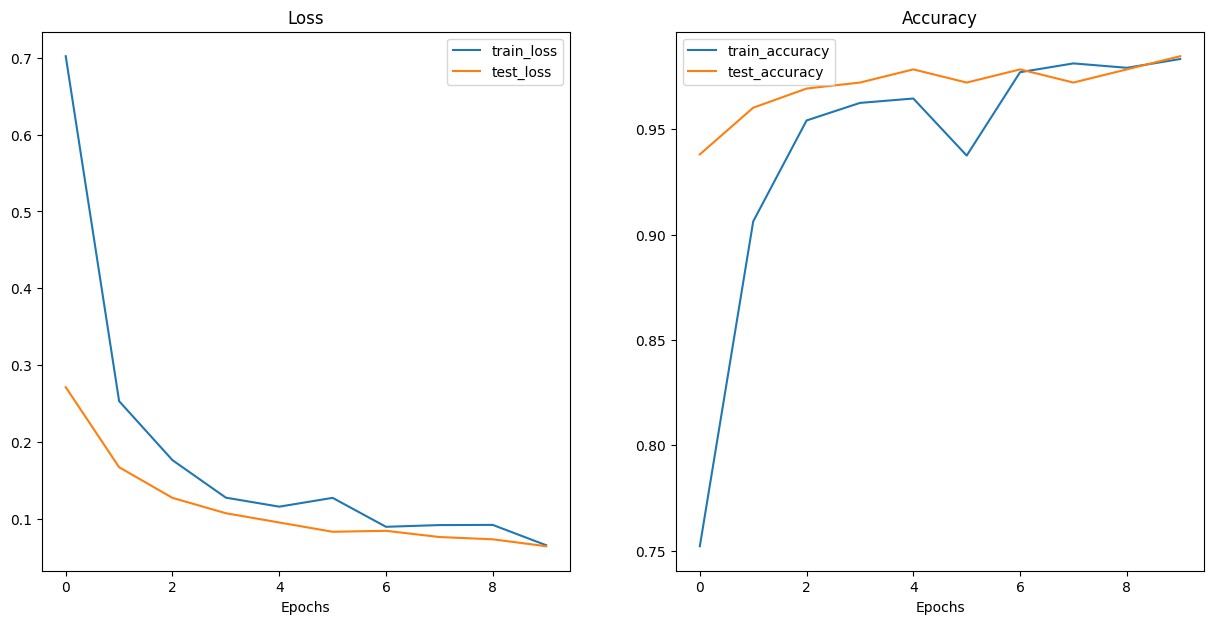

In [29]:
plot_loss_curves(vit_results)

In [31]:
#saving the vit feature extractor
from going_modular import utils
utils.save_model(model=vit,
                 target_dir="models",
                 model_name="10_pretrained_vit_feature_extractor_pizza_steak_sushi_20_percent.pth")

[INFO] Saving model to: models\10_pretrained_vit_feature_extractor_pizza_steak_sushi_20_percent.pth
